In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_approximation import Nystroem,RBFSampler
import gym

ModuleNotFoundError: No module named 'gym'

In [2]:
GAMMA=0.99
ALPHA=.1

In [3]:
def epsilon_greedy(model,s,esp=.1):
    p=np.random.random()
    if p<(1-esp):
        return np.argmax(model.predict_all_actions(s))
    else:
        return model.env.action_space.sample()

In [4]:
def gather_samples(env,n_episodes=10000):
    samples=[]
    for _ in range (n_episodes):
        s=env.reset()[0]
        done=False
        while not done:
            a=env.action_space.sample()
            sa=np.concatenate((s,[a]))
            samples.append(sa)
            
            s,r,done,info,i=env.step(a)
        
    return samples

In [5]:
class Model:
    def __init__(self,env):
        self.env=env
        samples=gather_samples(env)
        self.featurizer= RBFSampler()
        self.featurizer.fit(samples)
        dims= self.featurizer.n_components
        
        self.w=np.zeros(dims)
        
    def predict(self,s,a):
        sa=s.tolist()+[a]
        #sa=np.concatenate(s,[a])
        x=self.featurizer.transform([sa])[0]
        return x@ self.w
    
    def predict_all_actions(self,s):
        return [self.predict(s,a) for a in range(self.env.action_space.n)]
    
    def grad(self,s,a):
        #sa=np.concatenate(s,[a])
        sa=s.tolist()+[a]
        x= self.featurizer.transform([sa])[0]
        return x

In [10]:
def test_agent(model,env,n_episodes=20):
    reward_per_episode=np.zeros(n_episodes)
    for it in range(n_episodes):
        done=False
        episode_reward=0
        s= env.reset()[0]
        while not done:
            a= epsilon_greedy(model,s,esp=0)
            s,r,done,info,i=env.step(a)
            episode_reward +=r
            
        reward_per_episode[it]=episode_reward
    return np.max(reward_per_episode)
               

In [7]:
def watch_agent(model,env,eps):
    done=False
    episode_reward=0
    s= env.reset()[0]
    
    while not done:
        a= epsilon_greedy(model,s,eps)
        s,r,done,info,i=env.step(a)
        
        env.render()
        episode_reward +=r 
    print("Episode reward:",episode_reward)
        

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\gym\envs\registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


Episode reward: 10.0
Episode: 50, Reward:31.0
Episode: 100, Reward:28.0
Episode: 150, Reward:67.0
Episode: 200, Reward:43.0
Episode: 250, Reward:171.0
Episode: 300, Reward:68.0
Episode: 350, Reward:93.0
Episode: 400, Reward:36.0
Episode: 450, Reward:55.0
Episode: 500, Reward:80.0
Episode: 550, Reward:171.0
Episode: 600, Reward:108.0
Episode: 650, Reward:174.0
Episode: 700, Reward:194.0
Episode: 750, Reward:202.0
Episode: 800, Reward:208.0
Episode: 850, Reward:137.0
Episode: 900, Reward:154.0
Early exit
Average test reward: 169.0


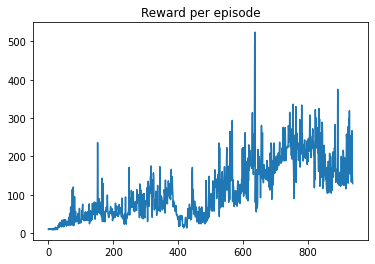

Episode reward: 117.0


In [11]:
if __name__=='__main__':
    environment_name = "CartPole-v0" #Env
    env = gym.make(environment_name, render_mode="rgb_array")
    model=Model(env)
    reward_per_episode=[]
    s=env.reset()[0]
    
    #watch untrained agent
    watch_agent(model,env,0)
    
    n_episodes=1500
    for it in range(n_episodes):
        s=env.reset()[0]
        episode_reward=0
        done=False
        while not done:
            a=epsilon_greedy(model,s)
            Vs=model.predict(s,a)
            g=model.grad(s,a)
        
            s2,r,done,info,i=env.step(a)
            
            if done:
                target =r 
            else:
                Vs2=model.predict_all_actions(s2)
                target= r+ GAMMA * np.max(Vs2)
            
            err= target -Vs
            
            model.w += ALPHA * err * g
            
            episode_reward +=r
            
            s=s2
            
        if (it+1)%50 ==0:
            print(f"Episode: {it+1}, Reward:{episode_reward}")
            
        if it>20 and np.mean(reward_per_episode[-20:])==200:
            print("Early exit")
            break
        
        reward_per_episode.append(episode_reward)
        
    test_reward= test_agent(model,env)
    print(f"Average test reward: {test_reward}")
    
    plt.plot(reward_per_episode)
    plt.title("Reward per episode")
    plt.show()
    
    
    watch_agent(model,env,eps=0)
        
            

            
        
            
            
            
            
            
        
            
        
        
        
            
        